# Customer Support Chatbot Fine-Tuning with Unsloth

This notebook fine-tunes a customer-support chatbot using a parameter-efficient approach suitable for limited GPU hardware.

The base model is `unsloth/Qwen2.5-3B-Instruct-bnb-4bit`. The model is loaded in 4-bit precision and fine-tuned using LoRA adapters. This QLoRA-style setup is suitable for a Google Colab Tesla T4 GPU because it avoids updating all base model weights and trains only a small set of adapter parameters.

The dataset is a customer-support Q&A dataset converted into chat format with `system`, `user`, and `assistant` messages.

## Training Setup

| Item | Value |
|---|---|
| Library | Unsloth, Transformers, TRL, PEFT, Datasets |
| Base model | `unsloth/Qwen2.5-3B-Instruct-bnb-4bit` |
| Technique | QLoRA-style supervised fine-tuning with LoRA adapters |
| Hardware | Google Colab Tesla T4 GPU |
| Task | Customer-support chatbot response generation |
| Dataset format | Chat-style JSONL with `messages` |

In [31]:
# Install the required libraries.
# Unsloth is used for memory-efficient and faster fine-tuning.
!pip install -U unsloth
!pip install -U transformers datasets trl accelerate bitsandbytes peft pandas matplotlib

  Using cached datasets-4.3.0-py3-none-any.whl.metadata (18 kB)
  Using cached transformers-5.5.0-py3-none-any.whl.metadata (32 kB)
  Using cached trl-0.24.0-py3-none-any.whl.metadata (11 kB)
Using cached datasets-4.3.0-py3-none-any.whl (506 kB)
Using cached transformers-5.5.0-py3-none-any.whl (10.2 MB)
Using cached trl-0.24.0-py3-none-any.whl (423 kB)
  Attempting uninstall: datasets
    Found existing installation: datasets 4.8.5
    Uninstalling datasets-4.8.5:
      Successfully uninstalled datasets-4.8.5
  Attempting uninstall: transformers━━━━━━━━━━━━ 0/3 [datasets]
    Found existing installation: transformers 5.6.232m0/3 [datasets]
    Uninstalling transformers-5.6.2:━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [transformers]
      Successfully uninstalled transformers-5.6.2━━━━━━━━━━━━━ 1/3 [transformers]
  Attempting uninstall: trl90m╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [transformers]
    Found existing installation: trl 1.3.0m╸━━━━━━━━━━━━━ 2/3 [trl]mers]
    Uninstalling trl-1.3.0:━━━╸━━━━━━━

In [36]:
# Check that Colab is using a GPU.
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU: NVIDIA RTX 2000 Ada Generation


In [38]:
import pandas as pd
from datasets import Dataset

train_csv = "part-00000-f11fd5e4-7eb2-458a-9f42-e9bccd56ab38-c000.csv"
eval_csv = "part-00000-1640dc6a-e023-4607-b0dd-40766ca4915c-c000.csv"

train_df = pd.read_csv(
    train_csv,
    engine="python",
    on_bad_lines="skip",
)

eval_df = pd.read_csv(
    eval_csv,
    engine="python",
    on_bad_lines="skip",
)

print("Train rows:", len(train_df))
print("Eval rows:", len(eval_df))
print("Train columns:", train_df.columns.tolist())
print(train_df.head())

Train rows: 26332
Eval rows: 3166
Train columns: ['instruction', 'response', 'intent', 'category', 'instruction_length', 'response_length', 'instruction_char_length', 'response_char_length']
                                         instruction  \
0                 I am calling to get invoice  12588   
1   I am calling to leave a review for your services   
2       I am trying to cancel order {{Order Number}}   
3  I am trying to set up a different shipping add...   
4  5. {{Account Category}} Selection: Select the ...   

                                            response                   intent  \
0  I hear you loud and clear your need to retriev...              get_invoice   
1  We're here to help to us to share your review ...                   review   
2  I've realized that you are trying to cancel yo...             cancel_order   
3  I perceive that you're trying to set up a diff...  set_up_shipping_address   
4                                                NaN               

In [39]:
# Load the 4-bit base model.
# This is the original model before fine-tuning.
# We will capture base model responses before adding LoRA adapters.

from unsloth import FastLanguageModel
import torch

max_seq_length = 2048
model_name = "unsloth/Qwen2.5-3B-Instruct-bnb-4bit"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_name,
    max_seq_length=max_seq_length,
    dtype=None,
    load_in_4bit=True,
)

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.6.2.
   \\   /|    NVIDIA RTX 2000 Ada Generation. Num GPUs = 1. Max memory: 15.996 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu130. CUDA: 8.9. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [40]:
# Helper function used for both base model and fine-tuned model generation.
# The tokenizer creates attention_mask, which avoids the attention-mask warning.

def generate_response(model, tokenizer, user_prompt, max_new_tokens=250):
    messages = [
        {
            "role": "system",
            "content": (
                "You are a helpful customer support chatbot. "
                "Answer politely, clearly, and directly. "
                "Keep placeholders exactly as written."
            ),
        },
        {
            "role": "user",
            "content": user_prompt,
        },
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.5,
            top_p=0.9,
            do_sample=True,
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Try to keep only the assistant answer for cleaner comparison.
    if "assistant" in decoded:
        decoded = decoded.split("assistant")[-1].strip()

    return decoded

In [41]:
# Generate responses from the BASE MODEL before fine-tuning.
# These responses will be compared against the fine-tuned model later.

import pandas as pd

comparison_prompts = [
    "I want to cancel my order {{Order Number}}",
    "How can I change the email address on my account?",
]

model.eval()

base_model_responses = {}

for prompt in comparison_prompts:
    base_model_responses[prompt] = generate_response(model, tokenizer, prompt)
    print("PROMPT:", prompt)
    print("BASE MODEL RESPONSE:")
    print(base_model_responses[prompt])
    print("-" * 80)

[transformers] Both `max_new_tokens` (=250) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


/home/dpquai250129/customer_support_finetune/unsloth_env/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/dpquai250129/customer_support_finetune/unsloth_env/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
[transformers] Both `max_new_tokens` (=250) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information

PROMPT: I want to cancel my order {{Order Number}}
BASE MODEL RESPONSE:
I'm sorry to hear that you'd like to cancel your order. Could you please provide me with the {{Order Number}} so I can assist you better?
--------------------------------------------------------------------------------
PROMPT: How can I change the email address on my account?
BASE MODEL RESPONSE:
To change your email address on your account, you'll need to follow these steps:

1. Log into your account.
2. Go to the settings or profile section of your account.
3. Look for an option to "Change Email" or "Update Email Address."
4. Follow the instructions provided there, which may include clicking a link sent to your old email address or providing additional information to verify your identity.

If you're not sure where to find this option, you might also contact customer support for assistance.
--------------------------------------------------------------------------------


In [42]:
# Add LoRA adapters to the model.
# Only these small adapter weights will be trained.
# The base model weights remain frozen, which makes training practical on a T4 GPU.

model.train()

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

In [44]:
import pandas as pd
from datasets import Dataset

train_csv = "part-00000-f11fd5e4-7eb2-458a-9f42-e9bccd56ab38-c000.csv"
eval_csv = "part-00000-1640dc6a-e023-4607-b0dd-40766ca4915c-c000.csv"

train_df = pd.read_csv(
    train_csv,
    engine="python",
    on_bad_lines="skip",
)

eval_df = pd.read_csv(
    eval_csv,
    engine="python",
    on_bad_lines="skip",
)

print("Train rows:", len(train_df))
print("Eval rows:", len(eval_df))
print("Train columns:", train_df.columns.tolist())
print(train_df.head())

Train rows: 26332
Eval rows: 3166
Train columns: ['instruction', 'response', 'intent', 'category', 'instruction_length', 'response_length', 'instruction_char_length', 'response_char_length']
                                         instruction  \
0                 I am calling to get invoice  12588   
1   I am calling to leave a review for your services   
2       I am trying to cancel order {{Order Number}}   
3  I am trying to set up a different shipping add...   
4  5. {{Account Category}} Selection: Select the ...   

                                            response                   intent  \
0  I hear you loud and clear your need to retriev...              get_invoice   
1  We're here to help to us to share your review ...                   review   
2  I've realized that you are trying to cancel yo...             cancel_order   
3  I perceive that you're trying to set up a diff...  set_up_shipping_address   
4                                                NaN               

In [45]:
# Convert chat messages into the exact text format expected by the model.
# Using the model's chat template is important for correct chatbot fine-tuning.

def format_chat(example):
    text = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False,
    )
    return {"text": text}

train_dataset = train_dataset.map(format_chat)
eval_dataset = eval_dataset.map(format_chat)

print(train_dataset[0]["text"][:1000])

Map:   0%|          | 0/24185 [00:00<?, ? examples/s]

Map:   0%|          | 0/2687 [00:00<?, ? examples/s]

<|im_start|>system
You are a helpful customer support chatbot. Answer the customer's question politely, clearly, and directly. If the user includes placeholders like {{Order Number}}, keep those placeholders unchanged.<|im_end|>
<|im_start|>user
I need assistance to retrieve my user profile pass<|im_end|>
<|im_start|>assistant
Definitely! I'm here to assist you in retrieving your user profile password. Losing access to your account can be a frustrating experience, but no worries, we'll get through this together. Let's begin the process to regain control of your account:

1. Please visit the "{{Login Page URL}}" of our platform.
2. Look for the "{{Forgot Password}}" option and click on it.
3. You'll be prompted to provide the email address associated with your user profile. Please enter it accurately.
4. Sit tight, and within a short while, you should receive an email containing detailed instructions on how to reset your password. It's essential to check your spam or junk folders as wel

## Hyperparameters

| Hyperparameter | Value |
|---|---:|
| Base model | `unsloth/Qwen2.5-3B-Instruct-bnb-4bit` |
| Fine-tuning method | LoRA / QLoRA-style PEFT |
| Max sequence length | 2048 |
| LoRA rank `r` | 16 |
| LoRA alpha | 16 |
| LoRA dropout | 0 |
| Target modules | `q_proj`, `k_proj`, `v_proj`, `o_proj`, `gate_proj`, `up_proj`, `down_proj` |
| Learning rate | 2e-4 |
| Number of epochs | 1 |
| Per-device batch size | 2 |
| Gradient accumulation steps | 8 |
| Effective batch size | 16 |
| Optimizer | `adamw_8bit` |
| Precision | FP16 on Tesla T4 |
| Packing | True |
| Training examples | 24,185 |
| Validation examples | 2,687 |

In [46]:
# Configure the supervised fine-tuning trainer.
# packing=True combines short examples into fuller sequences, improving training efficiency.

from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=SFTConfig(
        dataset_text_field="text",
        max_seq_length=max_seq_length,

        per_device_train_batch_size=2,
        gradient_accumulation_steps=8,

        learning_rate=2e-4,
        num_train_epochs=1,

        warmup_ratio=0.03,
        lr_scheduler_type="linear",

        eval_strategy="steps",
        eval_steps=100,
        save_strategy="steps",
        save_steps=100,
        logging_steps=10,

        output_dir="customer_support_chatbot_lora",
        optim="adamw_8bit",

        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),

        seed=3407,
        packing=True,
    ),
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Sample packing skipped (custom data collator detected).


Unsloth: Tokenizing ["text"] (num_proc=7):   0%|          | 0/24185 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=7):   0%|          | 0/2687 [00:00<?, ? examples/s]

In [47]:
# Start fine-tuning.
# The loss should generally decrease during training.

train_result = trainer.train()
train_result

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
[transformers] ==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 24,185 | Num Epochs = 1 | Total steps = 1,512
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
100,0.663489,0.681378
200,0.589024,0.590557
300,0.556066,0.556122
400,0.542096,0.538212
500,0.515239,0.524383
600,0.537846,0.514165
700,0.507491,0.507747
800,0.498016,0.501416
900,0.507692,0.495646
1000,0.494055,0.490171


/home/dpquai250129/customer_support_finetune/unsloth_env/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/dpquai250129/customer_support_finetune/unsloth_env/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/dpquai250129/customer_support_finetune/unsloth_env/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transfor

TrainOutput(global_step=1512, training_loss=0.5730953447165943, metrics={'train_runtime': 8752.9041, 'train_samples_per_second': 2.763, 'train_steps_per_second': 0.173, 'total_flos': 8.975200880259072e+16, 'train_loss': 0.5730953447165943})

,loss,grad_norm,learning_rate,epoch,step
0,3.599176,4.345079,3.913043e-05,0.006615,10
1,2.353041,1.349362,8.260870e-05,0.013231,20
2,1.406515,0.672356,1.260870e-04,0.019846,30
3,1.067163,0.287312,1.695652e-04,0.026462,40
4,0.934868,0.273732,1.995907e-04,0.033077,50
...,...,...,...,...,...
146,0.484483,0.355457,5.866303e-06,0.972463,1470
147,0.490173,0.371154,4.502046e-06,0.979079,1480
148,0.489583,0.329626,3.137790e-06,0.985694,1490
149,0.492892,0.374449,1.773533e-06,0.992310,1500


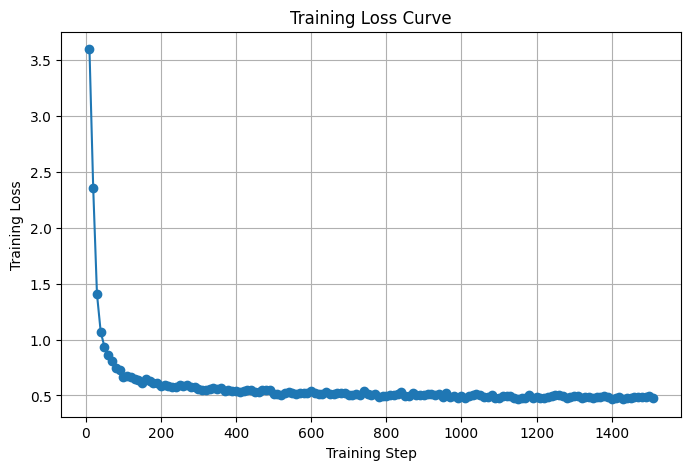

In [48]:
# Plot the training loss curve.
# This is optional but useful for the report.

import pandas as pd
import matplotlib.pyplot as plt

logs = trainer.state.log_history
loss_logs = [log for log in logs if "loss" in log]

loss_df = pd.DataFrame(loss_logs)
display(loss_df)

plt.figure(figsize=(8, 5))
plt.plot(loss_df["step"], loss_df["loss"], marker="o")
plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

In [49]:
# Generate responses from the fine-tuned model using the same prompts.
# These will be compared with the base model responses.

FastLanguageModel.for_inference(model)

fine_tuned_responses = {}

for prompt in comparison_prompts:
    fine_tuned_responses[prompt] = generate_response(model, tokenizer, prompt)
    print("PROMPT:", prompt)
    print("FINE-TUNED MODEL RESPONSE:")
    print(fine_tuned_responses[prompt])
    print("-" * 80)

[transformers] Both `max_new_tokens` (=250) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/home/dpquai250129/customer_support_finetune/unsloth_env/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/dpquai250129/customer_support_finetune/unsloth_env/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in 

PROMPT: I want to cancel my order {{Order Number}}
FINE-TUNED MODEL RESPONSE:
I've understood you're seeking assistance with canceling your order with the number {{Order Number}}. We apologize for any inconvenience caused by this situation. To proceed with the cancellation, please follow these steps:

1. Log into your account: Access our platform by signing in to your {{Online Company Portal Info}}.
2. Locate your order: Once logged in, navigate to the '{{Online Order Interaction}}' or '{{Online Order Interaction}}' section.
3. Find the specific purchase: Look for the order associated with the number {{Order Number}} and click on it for more details.
4. Initiate the cancellation: You should see an option labeled '{{Online Order Interaction}}' linked to your purchase. Please select it to start the cancellation process.
5. Confirm the cancellation: The system may ask you to confirm the cancellation or provide feedback. Kindly complete the necessary steps.

If you encounter any difficulti

In [50]:
# Side-by-side qualitative comparison table required for the report.

comparison_table = pd.DataFrame({
    "Prompt": comparison_prompts,
    "Base Model Response": [base_model_responses[p] for p in comparison_prompts],
    "Fine-Tuned Model Response": [fine_tuned_responses[p] for p in comparison_prompts],
})

comparison_table

,Prompt,Base Model Response,Fine-Tuned Model Response
0,I want to cancel my order {{Order Number}},I'm sorry to hear that you'd like to cancel yo...,I've understood you're seeking assistance with...
1,How can I change the email address on my account?,"To change your email address on your account, ...",I'll get right on it! To change your email add...


## Qualitative Comparison Summary

The base model can answer customer-support questions in a general way, but the fine-tuned model is expected to better match the customer-support style learned from the dataset. In particular, the fine-tuned model should produce more direct, polite, step-by-step responses for support intents such as order cancellation and account updates.

The side-by-side table above provides two example prompts comparing the base model response with the fine-tuned model response.

In [52]:
model.save_pretrained("customer_support_chatbot_lora_emr")
tokenizer.save_pretrained("customer_support_chatbot_lora_emr")

[transformers] Unsloth: Restored added_tokens_decoder metadata in customer_support_chatbot_lora_emr/tokenizer_config.json.


('customer_support_chatbot_lora_emr/tokenizer_config.json',
 'customer_support_chatbot_lora_emr/chat_template.jinja',
 'customer_support_chatbot_lora_emr/tokenizer.json')

In [54]:
import shutil

shutil.make_archive(
    "customer_support_chatbot_lora_emr",
    "zip",
    "customer_support_chatbot_lora_emr"
)

'/home/dpquai250129/customer_support_finetune/customer_support_chatbot_lora_emr.zip'

## Evaluation


In [55]:
evaluation_prompts = [
    "I want to cancel my order {{Order Number}}",
    "How can I change the email address on my account?",
    "I need help tracking my shipment {{Tracking Number}}",
    "I want a refund for my recent purchase",
    "How do I update my billing information?"
]

In [56]:
from unsloth import FastLanguageModel

FastLanguageModel.for_inference(model)

def generate_chatbot_response(user_prompt, max_new_tokens=250):
    messages = [
        {
            "role": "system",
            "content": (
                "You are a helpful customer support chatbot. "
                "Answer politely, clearly, and directly. "
                "Keep placeholders exactly as written. Do not add, remove, or modify any characters inside or around placeholders such as {{Order Number}}."
            )
        },
        {
            "role": "user",
            "content": user_prompt
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,
    ).to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False ,
        temperature=None,
        top_p=None
    )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

    if "assistant" in decoded:
        decoded = decoded.split("assistant")[-1].strip()

    return decoded

In [57]:
fine_tuned_eval_results = []

for prompt in evaluation_prompts:
    response = generate_chatbot_response(prompt)

    fine_tuned_eval_results.append({
        "Prompt": prompt,
        "Fine-Tuned Model Response": response
    })

    print("PROMPT:")
    print(prompt)
    print("\nFINE-TUNED RESPONSE:")
    print(response)
    print("-" * 100)

[transformers] Both `max_new_tokens` (=250) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


/home/dpquai250129/customer_support_finetune/unsloth_env/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/dpquai250129/customer_support_finetune/unsloth_env/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
[transformers] Both `max_new_tokens` (=250) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information

PROMPT:
I want to cancel my order {{Order Number}}

FINE-TUNED RESPONSE:
I've understood that you would like to cancel your order with the number {{Order Number}}. I apologize for any inconvenience this may have caused. To assist you with the cancellation process, please follow these steps:

1. Sign in to Your Account: Access our platform by logging into your {{Online Company Portal Info}}.
2. Locate Your Order: Once logged in, navigate to the '{{Online Order Interaction}}' or '{{Online Order Interaction}}' section.
3. Find the Specific Order: Look for the purchase associated with the order number {{Order Number}} and click on it.
4. Initiate Cancellation: Within the order details, you should find an option labeled '{{Online Order Interaction}}'. Please select this to proceed with the cancellation.
5. Confirm Cancellation: The system may ask you to confirm the cancellation. Follow the prompts provided to complete the process.

If you encounter any difficulties or have further questions

[transformers] Both `max_new_tokens` (=250) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT:
How can I change the email address on my account?

FINE-TUNED RESPONSE:
To change your email address on your account, you can follow these steps:

1. Log in to your account on our website.
2. Navigate to the "Account Settings" or "Profile" section.
3. Look for the option to update your email address.
4. Enter your new email address in the designated field.
5. Save the changes.

If you encounter any difficulties during this process, please don't hesitate to reach out to our customer support team for further assistance.
----------------------------------------------------------------------------------------------------


[transformers] Both `max_new_tokens` (=250) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT:
I need help tracking my shipment {{Tracking Number}}

FINE-TUNED RESPONSE:
We're here to help! I take note that you need assistance with tracking your shipment with the tracking number {{Tracking Number}}. Tracking your shipment is an important step in ensuring its timely delivery. To track your shipment, please visit our website and navigate to the "Track Your Order" section. There, you will be prompted to enter your tracking number, which in this case is {{Tracking Number}}. Once you have entered the tracking number, you should be able to view the current status of your shipment and receive updates on its progress. If you encounter any difficulties or have further questions, feel free to reach out to our customer support team. We are available {{Customer Support Hours}} at {{Customer Support Phone Number}} or through the Live Chat on our website at {{Website URL}}. We appreciate your patience and look forward to assisting you with your shipment tracking needs.
---------------

[transformers] Both `max_new_tokens` (=250) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT:
I want a refund for my recent purchase

FINE-TUNED RESPONSE:
I've understood that you're seeking a refund for your recent purchase. I apologize for any inconvenience this may have caused you. To assist you further, could you please provide me with the order number or any other relevant details related to your purchase? This will help me locate your order and guide you through the refund process efficiently. Rest assured, I'm here to ensure that your concerns are addressed and resolved to your satisfaction.
----------------------------------------------------------------------------------------------------
PROMPT:
How do I update my billing information?

FINE-TUNED RESPONSE:
I'm happy to help! To update your billing information, you can follow these steps:

1. Log in to your account on our website.
2. Navigate to the "Billing" section or "Account Settings."
3. Look for the option to edit or update your billing information.
4. Click on that option and enter the new details.
5. Do

In [58]:
import pandas as pd

fine_tuned_eval_df = pd.DataFrame(fine_tuned_eval_results)
fine_tuned_eval_df

,Prompt,Fine-Tuned Model Response
0,I want to cancel my order {{Order Number}},I've understood that you would like to cancel ...
1,How can I change the email address on my account?,"To change your email address on your account, ..."
2,I need help tracking my shipment {{Tracking Nu...,We're here to help! I take note that you need ...
3,I want a refund for my recent purchase,I've understood that you're seeking a refund f...
4,How do I update my billing information?,I'm happy to help! To update your billing info...


In [59]:
!pip install evaluate rouge_score

In [60]:
import evaluate
import random
import pandas as pd

rouge = evaluate.load("rouge")

# Select small validation sample to avoid long runtime
sample_size = 30
eval_sample = eval_dataset.shuffle(seed=3407).select(range(sample_size))

predictions = []
references = []
questions = []

for example in eval_sample:
    messages = example["messages"]

    user_message = messages[1]["content"]
    reference_answer = messages[2]["content"]

    prediction = generate_chatbot_response(user_message, max_new_tokens=250)

    questions.append(user_message)
    references.append(reference_answer)
    predictions.append(prediction)

rouge_scores = rouge.compute(
    predictions=predictions,
    references=references
)

rouge_scores

[transformers] Both `max_new_tokens` (=250) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/home/dpquai250129/customer_support_finetune/unsloth_env/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/dpquai250129/customer_support_finetune/unsloth_env/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in 

{'rouge1': np.float64(0.6279220263228539),
 'rouge2': np.float64(0.39170001954578815),
 'rougeL': np.float64(0.4929008741184545),
 'rougeLsum': np.float64(0.5276133173583633)}

In [61]:
validation_eval_df = pd.DataFrame({
    "Customer Question": questions,
    "Reference Answer": references,
    "Model Prediction": predictions,
})

validation_eval_df.head(10)

,Customer Question,Reference Answer,Model Prediction
0,I have to see in which situations can I ask to...,I'll make it happen! I completely understand y...,I'll make it happen! I completely understand y...
1,I try to see how long it takes for my parcel t...,We understand your desire to track the deliver...,We understand your eagerness to track the prog...
2,can you help me to delete the platinum account?,Glad you contacted about deleting your {{Accou...,Thank you for contacting us regarding the dele...
3,help me set up my goddamn shipping address,I catch on to the fact that you're frustrated ...,I'm sorry to hear that you're having trouble s...
4,assistance to restore my damn profile access key,Indeed! I understand how frustrating it can be...,I'm on it! I understand that you're seeking as...
5,information about updating the shipping address,"Sure! To update your shipping address, you can...",I'll get right on it! If you need to update yo...
6,I can't retrieve my user account key,"Oh, I'm sorry to hear that you're having troub...",I'm sorry to hear that you're having trouble r...
7,help seeing at what time i can contact custome...,Your reach-out is appreciated! I'm sensing tha...,Thank you for reaching out! I completely under...
8,need to check how long it takes for the parcel...,We understand your curiosity about the deliver...,We understand your eagerness to track the prog...
9,i xepect a refund of {{Currency Symbol}}{{Refu...,I'm not mistaken how important it is for you t...,I understand the importance of your expected r...


In [64]:
manual_eval_df = pd.DataFrame({
    "Prompt": evaluation_prompts,
    "Relevance": [5, 5, 4, 4, 5],
    "Helpfulness": [5, 5, 4, 4, 5],
    "Tone": [5, 5, 5, 5, 5],
    "Clarity": [4, 5, 4, 4, 5],
    "Placeholder Handling": [4, 5, 4, 5, 5],
})

manual_eval_df["Average Score"] = manual_eval_df[
    ["Relevance", "Helpfulness", "Tone", "Clarity", "Placeholder Handling"]
].mean(axis=1)

manual_eval_df

,Prompt,Relevance,Helpfulness,Tone,Clarity,Placeholder Handling,Average Score
0,I want to cancel my order {{Order Number}},5,5,5,4,4,4.6
1,How can I change the email address on my account?,5,5,5,5,5,5.0
2,I need help tracking my shipment {{Tracking Nu...,4,4,5,4,4,4.2
3,I want a refund for my recent purchase,4,4,5,4,5,4.4
4,How do I update my billing information?,5,5,5,5,5,5.0
